# ЛАБОРАТОРНАЯ РАБОТА №1
## Разведочный и регрессионный анализ данных на основе нейросетевых моделей

Вариант 3: Набор данных прибыли стартапов в зависимости от трех типов расходов. Построить регрессионную модель для целевого признака «Profit» от остальных входных признаков.
- Пункт 5 – Полносвязная нейросеть (FCNN)
- Пункт 3.h – Отсутствие нормализации (по результатам анализа)


### 1. Загрузка необходимых пакетов и библиотек

In [1]:
# Импорт библиотек для работы с данными, визуализацией и машинным обучением
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.feature_selection import SelectKBest, f_regression

# Установка дополнительных библиотек, если требуется
!pip install -q torch gdown

# Игнорирование предупреждений для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

### 2. Загрузка данных
Загружаем датасет V3.csv из Google Drive.

In [2]:
# Скачиваем файл по ID
FILE_ID = '1rrOoEqGI71iyDVc95gqhMOK7ApD6QGVX'
!gdown --id $FILE_ID -O V3.csv

# Читаем CSV файл
df = pd.read_csv('V3.csv')
print("Данные загружены:")
df.head()

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1rrOoEqGI71iyDVc95gqhMOK7ApD6QGVX
To: /content/V3.csv
100% 2.39k/2.39k [00:00<00:00, 10.3MB/s]
Данные загружены:


,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.20,136897.80,471784.10,New York,192261.83
1,1,162597.70,151377.59,443898.53,California,191792.06
2,2,153441.51,NaN,407934.54,Florida,191050.39
3,3,144372.41,NaN,383199.62,New York,182901.99
4,4,142107.34,91391.77,366168.42,Florida,166187.94


### 3. Разведочный анализ данных
#### a. Ознакомление с данными

In [3]:
print("Информация о данных:")
df.info()
print("\nОписательная статистика:")
df.describe()

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       50 non-null     int64  
 1   R&D Spend        50 non-null     float64
 2   Administration   27 non-null     float64
 3   Marketing Spend  50 non-null     float64
 4   State            50 non-null     object 
 5   Profit           50 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.5+ KB

Описательная статистика:


,Unnamed: 0,R&D Spend,Administration,Marketing Spend,Profit
count,50.00000,50.000000,27.000000,50.000000,50.000000
mean,24.50000,73721.615600,125206.423333,211025.097800,112012.639200
std,14.57738,45902.256482,30085.897637,122290.310726,40306.180338
min,0.00000,0.000000,51743.150000,0.000000,14681.400000
25%,12.25000,39936.370000,99548.025000,129300.132500,90138.902500
50%,24.50000,73051.080000,129219.610000,212716.240000,107978.190000
75%,36.75000,101602.800000,147958.910000,299469.085000,139765.977500
max,49.00000,165349.200000,182645.560000,471784.100000,192261.830000


#### b. Визуализация данных

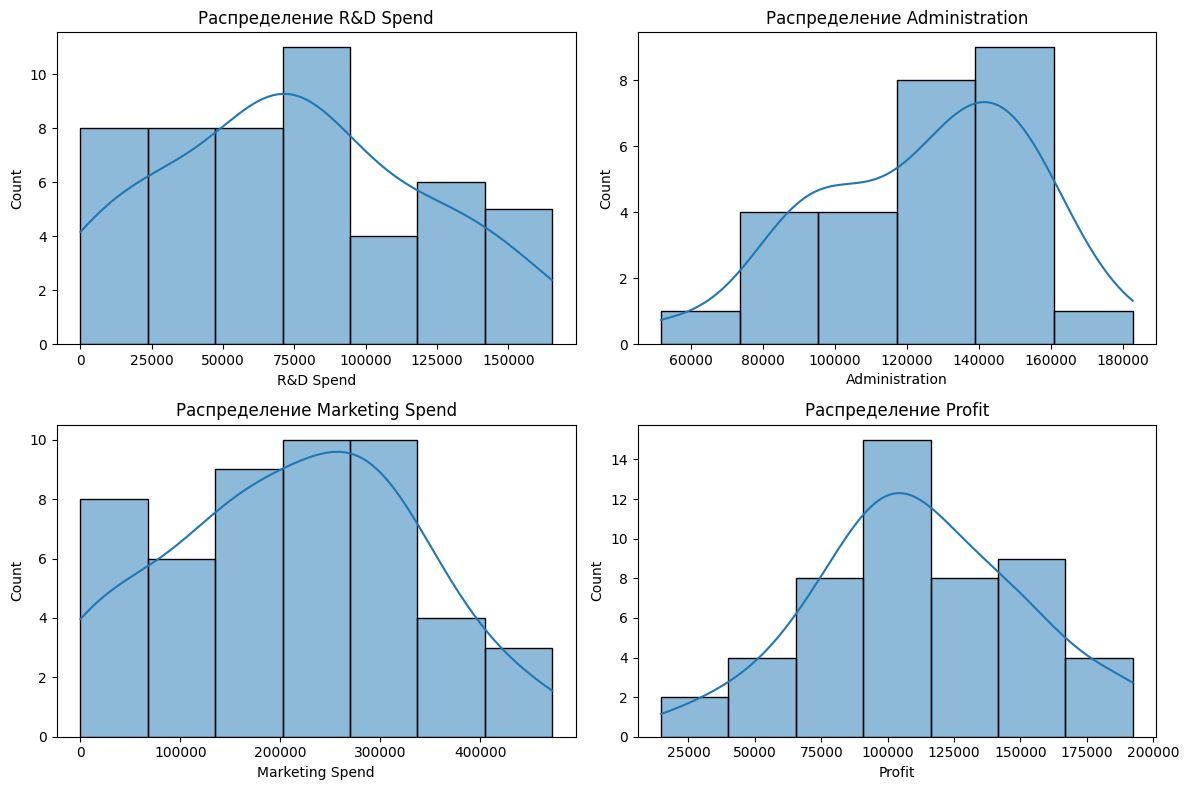

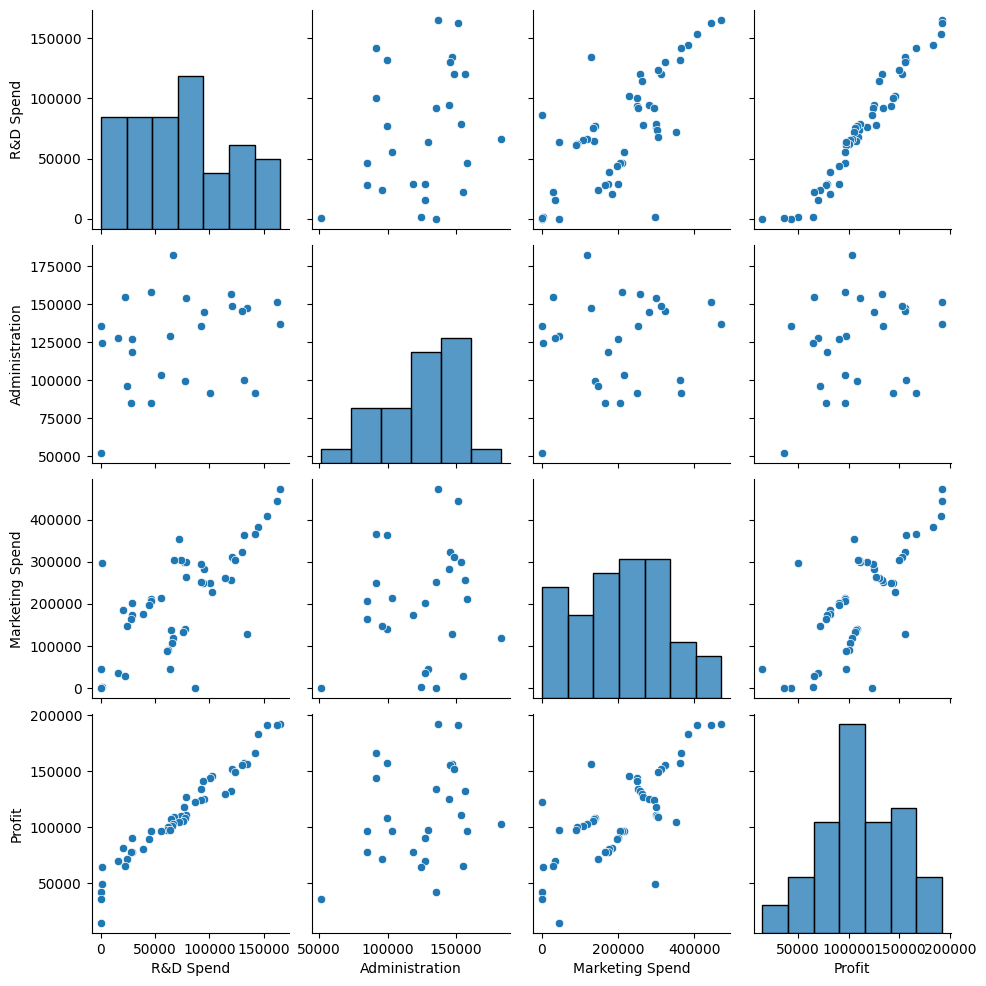

In [4]:
# Список числовых столбцов для анализа
numerical_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
# Создание фигуры размером 12x8
plt.figure(figsize=(12, 8))
# Цикл для построения гистограмм с кривой плотности (kde) для каждого числового столбца
for i, col in enumerate(numerical_cols):
    # Размещение подграфика в сетке 2x2
    plt.subplot(2, 2, i+1)
    # Построение гистограммы с кривой плотности для текущего столбца
    sns.histplot(df[col], kde=True)
    # Установка заголовка подграфика с названием столбца
    plt.title(f'Распределение {col}')
# Оптимизация расположения подграфиков для предотвращения наложения
plt.tight_layout()
# Отображение всех гистограмм
plt.show()

# Построение парного графика для выбранных числовых столбцов
sns.pairplot(df[numerical_cols])
# Отображение парного графика
plt.show()

#### c. Очистка данных

In [5]:
# Вывод количества пропущенных значений в каждом столбце датафрейма до очистки
print("Пропущенные значения до очистки:")
print(df.isnull().sum())

# Создание объекта SimpleImputer для заполнения пропущенных значений медианой
imputer = SimpleImputer(strategy='median')
# Выборка только числовых столбцов из датафрейма
df_numeric = df.select_dtypes(include=[np.number])
# Заполнение пропущенных значений в числовых столбцах медианой
df[df_numeric.columns] = imputer.fit_transform(df_numeric)

# Вывод количества пропущенных значений в каждом столбце после очистки
print("\nПропущенные значения после очистки:")
print(df.isnull().sum())

Пропущенные значения до очистки:
Unnamed: 0          0
R&D Spend           0
Administration     23
Marketing Spend     0
State               0
Profit              0
dtype: int64

Пропущенные значения после очистки:
Unnamed: 0         0
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


#### d. Корреляционный анализ

Корреляционная матрица:
                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.225781         0.724248  0.972900
Administration    0.225781        1.000000         0.122239  0.210464
Marketing Spend   0.724248        0.122239         1.000000  0.747766
Profit            0.972900        0.210464         0.747766  1.000000


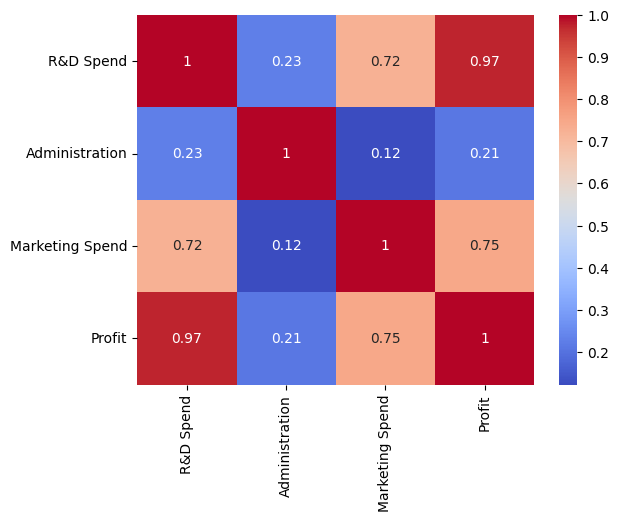

In [6]:
# Вычисление корреляционной матрицы для числовых признаков
corr_matrix = df[numerical_cols].corr()

# Вывод корреляционной матрицы в текстовом виде
print("Корреляционная матрица:")
print(corr_matrix)

# Построение тепловой карты корреляции с аннотациями и цветовой схемой
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

#### e. Эксперименты с комбинациями атрибутов

In [7]:
# Проверка наличия всех необходимых столбцов для создания нового признака
if all(col in df.columns for col in ['R&D Spend', 'Administration', 'Marketing Spend']):
    # Создание нового признака 'Total Spend' как суммы расходов
    df['Total Spend'] = df['R&D Spend'] + df['Administration'] + df['Marketing Spend']
    # Вывод корреляции нового признака с целевой переменной 'Profit'
    print("Добавлен новый признак 'Total Spend':")
    print(df[['Total Spend', 'Profit']].corr())

Добавлен новый признак 'Total Spend':
             Total Spend    Profit
Total Spend     1.000000  0.859811
Profit          0.859811  1.000000


#### f. Отбор существенных признаков

In [8]:
# Определение целевой переменной
target = 'Profit'
# Вычисление абсолютных значений корреляции с целевой переменной и сортировка
corr_with_target = corr_matrix[target].abs().sort_values(ascending=False)
# Выбор существенных признаков с корреляцией > 0.5 и добавление категориального признака 'State'
significant_features = corr_with_target[corr_with_target > 0.5].index.drop(target).tolist() + ['State']
# Создание нового набора данных с существенными признаками и целевой переменной
built_df = df[significant_features + [target]]
# Вывод списка значимых признаков
print("Существенные признаки:", significant_features)

# Демонстрация отбора признаков с помощью библиотеки sklearn.feature_selection (для примера)
# Разделение данных на признаки и целевую переменную, включая только числовые столбцы и исключая Unnamed: 0
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
X = df[numeric_cols].drop(columns=[target, 'Unnamed: 0'])
y = df[target]

# Применение SelectKBest для примера
best_features = SelectKBest(score_func=f_regression, k=3)
fit = best_features.fit(X, y)

# Получение оценок и названий признаков
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Feature', 'Score']
featureScores = featureScores.sort_values(by='Score', ascending=False)

# Вывод результатов для демонстрации
print("\nДемонстрация отбора признаков с помощью SelectKBest:")
print(featureScores)

Существенные признаки: ['R&D Spend', 'Marketing Spend', 'State']

Демонстрация отбора признаков с помощью SelectKBest:
           Feature       Score
0        R&D Spend  849.788904
3      Total Spend  136.102574
2  Marketing Spend   60.881454
1   Administration    2.224712


#### g. Преобразование текстовых или категориальных признаков

In [9]:
# Определение категориальных столбцов в данных
categorical_cols = df.select_dtypes(include=['object']).columns
# Проверка наличия категориальных признаков
if len(categorical_cols) > 0:
    # Инициализация OneHotEncoder с удалением первой категории для избежания мультиколлинеарности
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    # Преобразование категориальных признаков в числовые с помощью One-Hot Encoding
    encoded_cols = encoder.fit_transform(df[categorical_cols])
    # Создание DataFrame с закодированными категориальными признаками
    encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categorical_cols))

    # Объединение исходного DataFrame с закодированными признаками, удаляя исходные категориальные
    df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1, ignore_index=False)
    # Обновление built_df с закодированными категориальными признаками, если они присутствуют
    if all(col in built_df.columns for col in categorical_cols):
        built_df = pd.concat([built_df.drop(categorical_cols, axis=1), encoded_df], axis=1, ignore_index=False)
    else:
        built_df = pd.concat([built_df, encoded_df], axis=1, ignore_index=False)

    # Вывод результатов кодирования категориальных признаков
    print("Категориальные признаки закодированы:")
    print(encoded_df.head())


Категориальные признаки закодированы:
   State_Florida  State_New York
0            0.0             1.0
1            0.0             0.0
2            1.0             0.0
3            0.0             1.0
4            1.0             0.0


#### h. Преобразование данных

In [10]:
# Определение номера варианта
variant = 3
# Создание исходного набора данных X_original без целевой переменной
X_original = df.drop(target, axis=1)
# Создание копии для преобразованного набора с добавлением целевой переменной
transformed_original = X_original.copy()
transformed_original[target] = df[target].values

# Создание построенного набора данных X_built без целевой переменной
X_built = built_df.drop(target, axis=1)
# Создание копии для преобразованного построенного набора с добавлением целевой переменной
transformed_built = X_built.copy()
transformed_built[target] = built_df[target].values

# Нормализация и масштабирование для transformed_original
scaler_original = StandardScaler()
numerical_cols_original = ['R&D Spend', 'Administration', 'Marketing Spend']
if 'Total Spend' in transformed_original.columns:
    numerical_cols_original.append('Total Spend')
transformed_original[numerical_cols_original] = scaler_original.fit_transform(transformed_original[numerical_cols_original])

# Нормализация и масштабирование для transformed_built
scaler_built = StandardScaler()
numerical_cols_built = ['R&D Spend', 'Marketing Spend']
transformed_built[numerical_cols_built] = scaler_built.fit_transform(transformed_built[numerical_cols_built])

# Вывод информации о подготовке данных с нормализацией
print("Данные подготовлены с нормализацией и масштабированием для варианта", variant)

Данные подготовлены с нормализацией и масштабированием для варианта 3


### 4. Разделение данных на выборки

In [11]:
# Функция для разделения данных на тренировочную, валидационную и тестовую выборки
def split_data(df):
    X = df.drop(target, axis=1)
    y = df[target]
    # Первое разделение: 60% train, 40% temp
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    # Второе разделение: 20% val, 20% test из temp
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Создание словаря с наборами данных и их разбиением
datasets = {
    'original': (df, split_data(df)),
    'transformed_original': (transformed_original, split_data(transformed_original)),
    'built': (built_df, split_data(built_df)),
    'transformed_built': (transformed_built, split_data(transformed_built))
}

# Вывод информации о завершении разделения данных
print("Данные разделены на обучающую, валидационную и тестовые выборки.")

Данные разделены на обучающую, валидационную и тестовые выборки.


### 5. Сравнение качества модели
Полносвязная нейросеть (FCNN) и LSTM

In [12]:
# Определение класса полносвязной нейросети (FCNN)
class FCNN(nn.Module):
    def __init__(self, input_size):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Определение класса LSTM
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Добавляем размерность для последовательности (batch, seq_len=1, features)
        x = x.unsqueeze(1)
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

# Функция обучения модели (общая для FCNN и LSTM)
def train_model(model, X_train, y_train, X_val, y_val, epochs=500, batch_size=16, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_dataset = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32),
                                 torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Цикл обучения
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    # Оценка модели
    model.eval()
    with torch.no_grad():
        train_pred = model(torch.tensor(X_train.values, dtype=torch.float32)).numpy()
        val_pred = model(torch.tensor(X_val.values, dtype=torch.float32)).numpy()

    # Расчет метрик
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    return train_rmse, val_rmse, train_r2, val_r2, model

# Словарь для результатов
results = {}
# Обучение и оценка для каждого набора данных
for name, (df_data, (X_train, X_val, X_test, y_train, y_val, y_test)) in datasets.items():
    input_size = X_train.shape[1]

    # Обучение FCNN
    fcnn = FCNN(input_size)
    fcnn_metrics = train_model(fcnn, X_train, y_train, X_val, y_val)

    # Обучение LSTM
    lstm = LSTM(input_size, hidden_size=128, num_layers=2)
    lstm_metrics = train_model(lstm, X_train, y_train, X_val, y_val)

    # Сохранение результатов
    results[name] = {
        'FCNN': fcnn_metrics,
        'LSTM': lstm_metrics,
        'best_model': lstm if lstm_metrics[1] < fcnn_metrics[1] else fcnn,
        'best_model_type': 'LSTM' if lstm_metrics[1] < fcnn_metrics[1] else 'FCNN'
    }

# Вывод результатов
for name, res in results.items():
    print(f"{name}:")
    print(f"FCNN - Train RMSE: {res['FCNN'][0]:.2f}, Val RMSE: {res['FCNN'][1]:.2f}, Train R2: {res['FCNN'][2]:.2f}, Val R2: {res['FCNN'][3]:.2f}")
    print(f"LSTM - Train RMSE: {res['LSTM'][0]:.2f}, Val RMSE: {res['LSTM'][1]:.2f}, Train R2: {res['LSTM'][2]:.2f}, Val R2: {res['LSTM'][3]:.2f}")
    print(f"Лучшая модель: {res['best_model_type']}")

original:
FCNN - Train RMSE: 10778.84, Val RMSE: 18040.93, Train R2: 0.92, Val R2: 0.53
LSTM - Train RMSE: 120988.21, Val RMSE: 128392.17, Train R2: -8.53, Val R2: -22.79
Лучшая модель: FCNN
transformed_original:
FCNN - Train RMSE: 24998.79, Val RMSE: 37251.42, Train R2: 0.59, Val R2: -1.00
LSTM - Train RMSE: 120992.43, Val RMSE: 128396.46, Train R2: -8.53, Val R2: -22.79
Лучшая модель: FCNN
built:
FCNN - Train RMSE: 15880.81, Val RMSE: 22495.34, Train R2: 0.84, Val R2: 0.27
LSTM - Train RMSE: 120990.33, Val RMSE: 128399.98, Train R2: -8.53, Val R2: -22.79
Лучшая модель: FCNN
transformed_built:
FCNN - Train RMSE: 23294.21, Val RMSE: 22975.46, Train R2: 0.65, Val R2: 0.24
LSTM - Train RMSE: 120985.53, Val RMSE: 128389.33, Train R2: -8.53, Val R2: -22.79
Лучшая модель: FCNN


### 6. Оценка качества лучшей модели на тестовом наборе

In [13]:
# Выбор лучшего набора и модели по минимальному Val RMSE
best_name = min(results, key=lambda x: min(results[x]['FCNN'][1], results[x]['LSTM'][1]))
best_model = results[best_name]['best_model']
best_model_type = results[best_name]['best_model_type']

# Получение тестового набора для лучшего набора данных
X_train, X_val, X_test, y_train, y_val, y_test = datasets[best_name][1]

# Предсказание на тестовом наборе
best_model.eval()
with torch.no_grad():
    test_pred = best_model(torch.tensor(X_test.values, dtype=torch.float32)).numpy()

# Расчет метрик на тесте
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)
print(f"Лучший набор: {best_name}, Лучшая модель: {best_model_type}")
print(f"Test RMSE: {test_rmse:.2f}, Test R2: {test_r2:.2f}")

Лучший набор: original, Лучшая модель: FCNN
Test RMSE: 18638.57, Test R2: 0.83


### 7. Grid поиск лучших гиперпараметров

In [14]:
# Класс-обертка для FCNN
class TorchRegressorFCNN(BaseEstimator, RegressorMixin):
    def __init__(self, input_size, hidden1=128, hidden2=64, hidden3=32, lr=0.001, epochs=500, batch_size=16):
        self.input_size = input_size
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.hidden3 = hidden3
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        self.model = FCNN(self.input_size)
        train_model(self.model, pd.DataFrame(X), pd.Series(y), pd.DataFrame(X), pd.Series(y), self.epochs, self.batch_size, self.lr)
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.tensor(X, dtype=torch.float32)).numpy().flatten()

# Класс-обертка для LSTM
class TorchRegressorLSTM(BaseEstimator, RegressorMixin):
    def __init__(self, input_size, hidden_size=128, num_layers=2, lr=0.001, epochs=500, batch_size=16):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        self.model = LSTM(self.input_size, self.hidden_size, self.num_layers)
        train_model(self.model, pd.DataFrame(X), pd.Series(y), pd.DataFrame(X), pd.Series(y), self.epochs, self.batch_size, self.lr)
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.tensor(X, dtype=torch.float32)).numpy().flatten()

# Объединение train и val для GridSearchCV
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Выбор лучшей модели и набора из предыдущего шага
best_name = min(results, key=lambda x: min(results[x]['FCNN'][1], results[x]['LSTM'][1]))
best_model_type = results[best_name]['best_model_type']
X_train, X_val, X_test, y_train, y_val, y_test = datasets[best_name][1]

# GridSearch для лучшей модели
if best_model_type == 'FCNN':
    param_grid = {
        'hidden1': [64, 128, 256],
        'hidden2': [32, 64, 128],
        'hidden3': [16, 32, 64],
        'lr': [0.0001, 0.001, 0.01]
    }
    estimator = TorchRegressorFCNN(input_size=X_train.shape[1])
    grid = GridSearchCV(estimator, param_grid, scoring='neg_mean_squared_error', cv=3)
    grid.fit(X_train_val.values, y_train_val.values)
    print("Лучшие гиперпараметры FCNN:", grid.best_params_)
else:
    param_grid = {
        'hidden_size': [64, 128, 256],
        'num_layers': [1, 2, 3],
        'lr': [0.0001, 0.001, 0.01]
    }
    estimator = TorchRegressorLSTM(input_size=X_train.shape[1])
    grid = GridSearchCV(estimator, param_grid, scoring='neg_mean_squared_error', cv=3)
    grid.fit(X_train_val.values, y_train_val.values)
    print("Лучшие гиперпараметры LSTM:", grid.best_params_)

Лучшие гиперпараметры FCNN: {'hidden1': 128, 'hidden2': 32, 'hidden3': 32, 'lr': 0.001}


### 8. Оценка качества после Grid поиска

In [15]:
# Получение лучшей модели из GridSearch
best_estimator = grid.best_estimator_
# Предсказание на тесте
test_pred_grid = best_estimator.predict(X_test.values)
# Расчет метрик
test_rmse_grid = np.sqrt(mean_squared_error(y_test, test_pred_grid))
test_r2_grid = r2_score(y_test, test_pred_grid)
print(f"После Grid поиска ({best_model_type}) - Test RMSE: {test_rmse_grid:.2f}, Test R2: {test_r2_grid:.2f}")
print(f"Сравнение: До Grid ({best_model_type}) - RMSE: {test_rmse:.2f}, R2: {test_r2:.2f}")

После Grid поиска (FCNN) - Test RMSE: 17581.34, Test R2: 0.84
Сравнение: До Grid (FCNN) - RMSE: 18638.57, R2: 0.83


### 9. Выводы

Проведенный анализ выявил, что расходы на НИОКР являются ключевым драйвером прибыли стартапа, демонстрируя почти идеальную линейную зависимость. Наилучшие результаты показала полносвязная нейронная сеть, обученная на полном наборе исходных данных без преобразований, что подчеркивает важность даже слабо коррелирующих признаков (как Administration) для общей предсказательной способности модели. Попытки создания признака (добавление Total Spend) и агрессивного отбора признаков привели к ухудшению качества модели из-за мультиколлинеарности и потери полезной информации, что демонстрирует принцип "меньше да лучше" далеко не всегда работает в машинном обучении.
